In [ ]:
!pip install scanpy==1.9.3 anndata==0.8.0
!pip install scikit-learn
!pip install matplotlib
!pip install pandas
!pip install numpy
!pip install harmonypy
!pip install scvi-tools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.1/96.1 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.6/87.6 kB 9.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 10.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 662.1/662.1 kB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 74.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 77.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.3/174.3 kB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 113.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 20.7 MB/s eta 0:00:00
  

In [ ]:
import scanpy as sc
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns

In [ ]:
# mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Dataset

In [ ]:
# import anndata as ad

data_path = "/content/drive/MyDrive/GP_datasets/Pancreas/Baron_Pancreas_Combined_Human_Mouse.h5ad"


In [ ]:
# read adata
adata = sc.read_h5ad(data_path)

In [ ]:
print(adata)

AnnData object with n_obs × n_vars = 9436 × 10335
    obs: 'barcode', 'cell_type', 'donor_batch', 'source', 'species', 'batch'


In [ ]:
# check cell_types
adata.obs['cell_type'].value_counts()
print(adata.obs)

                                                barcode           cell_type  \
0-mouse_1                            AAGTGAAAG-CGACTCCT                beta   
1-mouse_1                             TGCAAGGG-GGCATGCT              ductal   
2-mouse_1                           GAGAGCCCAT-CTTCTGGA               delta   
3-mouse_1                             AAATCAGA-GTTGCACG             schwann   
4-mouse_1                           GAGGCGTTAG-GGCTACTA               delta   
...                                                 ...                 ...   
human4_lib3.final_cell_0697-human   GAGATCTCGG-GTCTCTCT  activated_stellate   
human4_lib3.final_cell_0698-human     GCTTACCT-ATGTTGGC               alpha   
human4_lib3.final_cell_0699-human  TGACACAGTTT-TTGTCGCC                beta   
human4_lib3.final_cell_0700-human   GACGACTCCT-CGCTAATA                beta   
human4_lib3.final_cell_0701-human     TGATGCCC-TTGCACGC              ductal   

                                  donor_batch      

## Normalization

In [ ]:
# make sure there is a counts layer for scvi
adata.layers["counts"] = adata.X

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [ ]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw = adata  # keep full dimension safe
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=4000,
    flavor="seurat_v3",
    layer="counts",
    subset=True,
    batch_key="species",  #
)

=== Logistic Regression (k-fold) ===
Accuracy: 0.9882226980728052
                    precision    recall  f1-score   support

activated_stellate       1.00      1.00      1.00        14
             alpha       0.97      0.99      0.98       191
              beta       1.00      1.00      1.00       894
             delta       0.97      0.97      0.97       218
            ductal       1.00      0.99      0.99       275
       endothelial       1.00      0.99      1.00       139
             gamma       0.90      0.88      0.89        41
        macrophage       1.00      1.00      1.00        36
quiescent_stellate       0.98      0.98      0.98        47
           schwann       1.00      1.00      1.00         6
            t_cell       1.00      0.86      0.92         7

          accuracy                           0.99      1868
         macro avg       0.98      0.97      0.98      1868
      weighted avg       0.99      0.99      0.99      1868



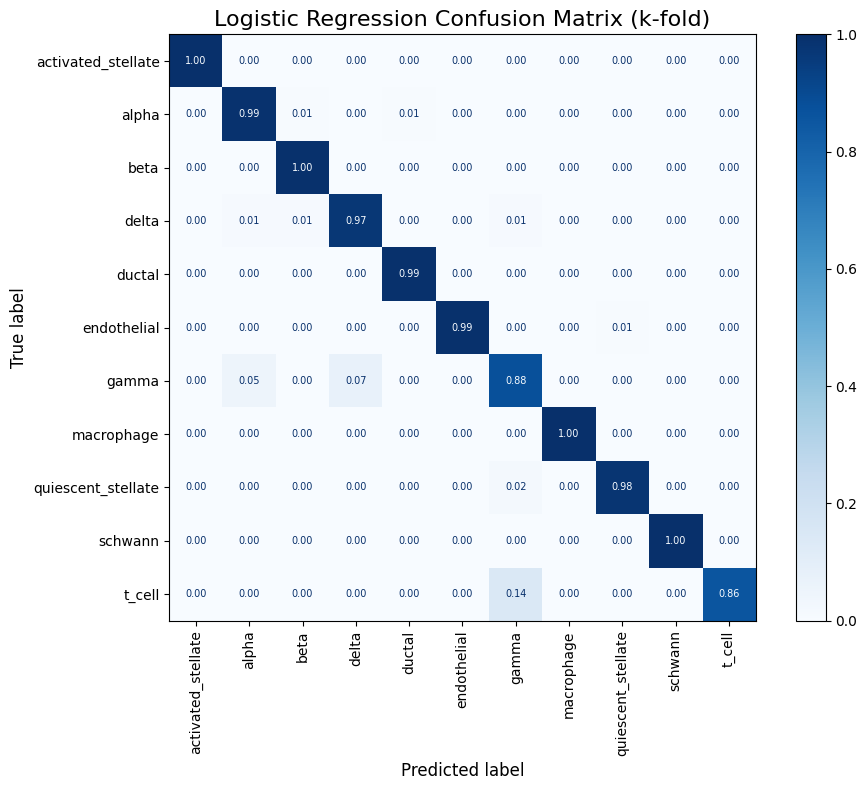


=== k-NN  (k-fold) ===
Accuracy: 0.9876873661670236
                    precision    recall  f1-score   support

activated_stellate       1.00      1.00      1.00        14
             alpha       0.96      0.98      0.97       191
              beta       1.00      0.99      0.99       894
             delta       0.98      0.97      0.97       218
            ductal       1.00      1.00      1.00       275
       endothelial       1.00      0.99      1.00       139
             gamma       0.95      0.93      0.94        41
        macrophage       0.92      1.00      0.96        36
quiescent_stellate       1.00      0.98      0.99        47
           schwann       1.00      1.00      1.00         6
            t_cell       1.00      0.71      0.83         7

          accuracy                           0.99      1868
         macro avg       0.98      0.96      0.97      1868
      weighted avg       0.99      0.99      0.99      1868



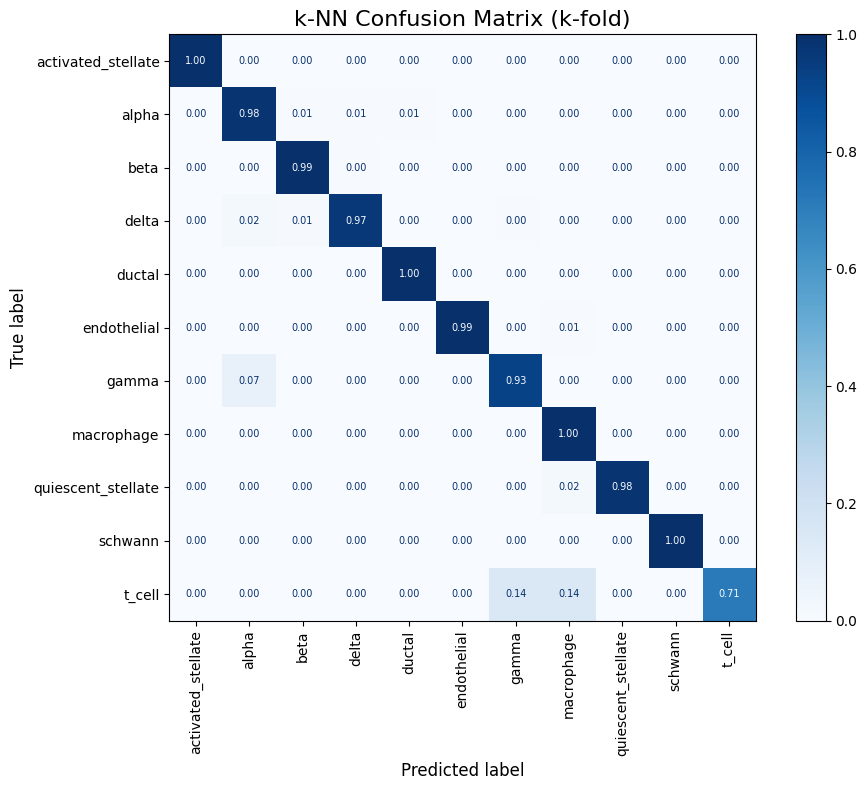

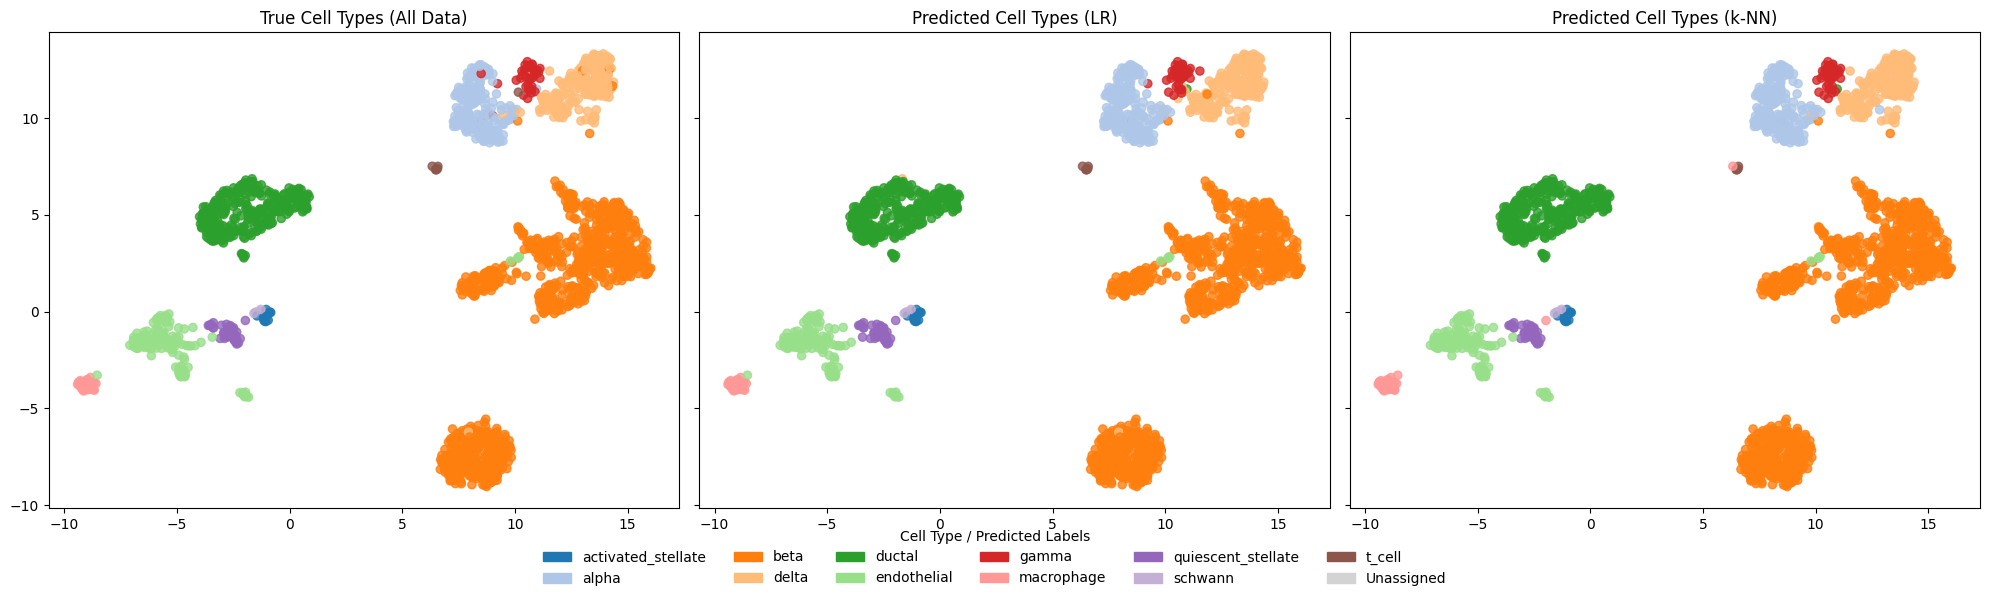

In [ ]:
## Build a cell-type classifier for regular annotation

from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

#mouse data subset
adata_1 = adata[adata.obs["species"] == "mouse"]


# hvg
sc.pp.highly_variable_genes(adata_1, n_top_genes=4000)
sc.pp.pca(adata_1, n_comps=50)

# logistic regression with cross-validation

clf_kfold = LogisticRegression(max_iter=300, solver='lbfgs')

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
x_kfold = adata_1.obsm["X_pca"]
y_kfold = adata_1.obs["cell_type"]
y_pred_lr_kfold = cross_val_predict(clf_kfold, x_kfold , y_kfold, cv=kf)

# knn with cross-validation
from sklearn.neighbors import KNeighborsClassifier
# knn
# train
knn_kfold = KNeighborsClassifier(n_neighbors=15,
    weights="distance",
    metric="cosine")
knn_kfold.fit(x_kfold, y_kfold)
# test
y_pred_knn_kfold = cross_val_predict(knn_kfold, x_kfold , y_kfold, cv=kf)

# Fill missing predicted labels
adata_1.obs['y_pred_lr_kfold'] = pd.Series(y_pred_lr_kfold, index=adata_1.obs_names).astype(str).fillna('Unassigned')
adata_1.obs['y_pred_knn_kfold'] = pd.Series(y_pred_knn_kfold, index=adata_1.obs_names).astype(str).fillna('Unassigned')


def plot_cm(y_true, y_pred, title):
    labels = np.unique(y_true)
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")

    fig, ax = plt.subplots(figsize=(10, 8), dpi=100)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=labels)

    disp.plot(
        ax=ax,
        cmap="Blues",
        xticks_rotation=90,
        values_format=".2f",
        colorbar=True
    )

    # Make text smaller
    for text in ax.texts:
        text.set_fontsize(7)

    plt.title(title, fontsize=16)
    plt.xlabel("Predicted label", fontsize=12)
    plt.ylabel("True label", fontsize=12)

    plt.tight_layout()
    plt.show()

print("=== Logistic Regression (k-fold) ===")
print("Accuracy:", accuracy_score(y_kfold, y_pred_lr_kfold))
print(classification_report(y_kfold, y_pred_lr_kfold))
plot_cm(y_kfold, y_pred_lr_kfold, "Logistic Regression Confusion Matrix (k-fold)")


print("\n=== k-NN  (k-fold) ===")
print("Accuracy:", accuracy_score(y_kfold, y_pred_knn_kfold))
print(classification_report(y_kfold, y_pred_knn_kfold))
plot_cm(y_kfold, y_pred_knn_kfold, "k-NN Confusion Matrix (k-fold)")


sc.pp.neighbors(adata_1, n_neighbors=15, n_pcs=50)
sc.tl.umap(adata_1)

# Combine all labels
all_labels = np.unique(np.concatenate([
    adata_1.obs["cell_type"].to_numpy(),
    adata_1.obs['y_pred_lr_kfold'].to_numpy(),
    adata_1.obs['y_pred_knn_kfold'].to_numpy()
]))

# Create consistent color map
palette = sc.pl.palettes.vega_20
label_to_color = {lbl: palette[i % len(palette)] for i, lbl in enumerate(all_labels)}
label_to_color['Unassigned'] = 'lightgray'

# Add color columns to adata
adata_1.obs['color_true'] = adata_1.obs['cell_type'].map(label_to_color)
adata_1.obs['color_lr'] = adata_1.obs['y_pred_lr_kfold'].map(label_to_color)
adata_1.obs['color_knn'] = adata_1.obs['y_pred_knn_kfold'].map(label_to_color)

# Plot side by side
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharex=True, sharey=True)

axes[0].scatter(adata_1.obsm['X_umap'][:,0], adata_1.obsm['X_umap'][:,1],
                c=adata_1.obs['color_true'], s=35, alpha=0.8)
axes[0].set_title('True Cell Types (All Data)')

axes[1].scatter(adata_1.obsm['X_umap'][:,0], adata_1.obsm['X_umap'][:,1],
                c=adata_1.obs['color_lr'], s=35, alpha=0.8)
axes[1].set_title('Predicted Cell Types (LR)')

axes[2].scatter(adata_1.obsm['X_umap'][:,0], adata_1.obsm['X_umap'][:,1],
                c=adata_1.obs['color_knn'], s=35, alpha=0.8)
axes[2].set_title('Predicted Cell Types (k-NN)')

# Shared legend
handles = [Patch(color=color, label=lbl) for lbl, color in label_to_color.items()]
fig.legend(handles=handles, title='Cell Type / Predicted Labels', loc='lower center', ncol=6, frameon=False)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()
